## Customer Churn Definition

Customer churn refers to customers who stop purchasing from the business over time. The objective of churn prediction is to identify customers who are likely to stop buying in the future.

The dataset used in this project does not contain an explicit churn label such as:
- Churn = Yes/No

Therefore, churn labels were created manually using a Recency-based business rule.

Customers who have not made a purchase for a long period are considered churned customers.

### Churn Rule

If:

Recency > 180 days

Then:
- Customer = Churned (1)

Else:
- Customer = Active (0)

In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [23]:
df = pd.read_csv("../data/processed/cleaned_retail_data.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [24]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [25]:
customer_features = df.groupby("Customer ID").agg({

    "InvoiceDate": [
        lambda x: (snapshot_date - x.max()).days,
        lambda x: (x.max() - x.min()).days
    ],

    "Invoice": "nunique",

    "Revenue": ["sum", "mean"],

    "Quantity": ["sum", "mean"]

})

In [26]:
customer_features.columns = [

    "Recency",
    "ActiveDays",

    "Frequency",

    "Monetary",
    "AvgOrderValue",

    "TotalQuantity",
    "AvgQuantity"
]

In [27]:
customer_features["Churn"] = np.where(
    customer_features["Recency"] > 180,
    1,
    0
)

In [28]:
X = customer_features[[
    "Frequency",
    "Monetary",
    "AvgOrderValue",
    "TotalQuantity",
    "AvgQuantity",
    "ActiveDays"
]]

y = customer_features["Churn"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [31]:
# Function to calculate Precision@Top 20%

def precision_at_top_20(y_test, y_prob):
    results = pd.DataFrame({
        "Actual": y_test,
        "Churn_Probability": y_prob
    })

    results = results.sort_values(
        by="Churn_Probability",
        ascending=False
    )

    top_20_percent = int(len(results) * 0.20)

    top_20_customers = results.head(top_20_percent)

    return top_20_customers["Actual"].mean()

In [32]:
# Random Forest Model

rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, rf_prob)
rf_precision_top20 = precision_at_top_20(y_test, rf_prob)

print("Random Forest Results")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", rf_auc)
print("Precision@Top20%:", rf_precision_top20)

Random Forest Results
              precision    recall  f1-score   support

           0       0.84      0.72      0.77       695
           1       0.66      0.79      0.72       478

    accuracy                           0.75      1173
   macro avg       0.75      0.76      0.75      1173
weighted avg       0.76      0.75      0.75      1173

ROC-AUC: 0.8176891123084795
Precision@Top20%: 0.717948717948718


In [33]:
# XGBoost Model

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_auc = roc_auc_score(y_test, xgb_prob)
xgb_precision_top20 = precision_at_top_20(y_test, xgb_prob)

print("XGBoost Results")
print(classification_report(y_test, xgb_pred))
print("ROC-AUC:", xgb_auc)
print("Precision@Top20%:", xgb_precision_top20)

XGBoost Results
              precision    recall  f1-score   support

           0       0.79      0.74      0.76       695
           1       0.65      0.71      0.68       478

    accuracy                           0.73      1173
   macro avg       0.72      0.72      0.72      1173
weighted avg       0.73      0.73      0.73      1173

ROC-AUC: 0.8035173534812318
Precision@Top20%: 0.7008547008547008


In [34]:
# Model Comparison Table

model_comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "ROC_AUC": [rf_auc, xgb_auc],
    "Precision_Top20": [rf_precision_top20, xgb_precision_top20]
})

model_comparison

,Model,ROC_AUC,Precision_Top20
0,Random Forest,0.817689,0.717949
1,XGBoost,0.803517,0.700855


In [35]:
# Select best model based on ROC-AUC

if rf_auc >= xgb_auc:
    best_model = rf_model
    best_model_name = "Random Forest"
    y_pred = rf_pred
    y_prob = rf_prob
else:
    best_model = xgb_model
    best_model_name = "XGBoost"
    y_pred = xgb_pred
    y_prob = xgb_prob

print("Best Model:", best_model_name)

Best Model: Random Forest


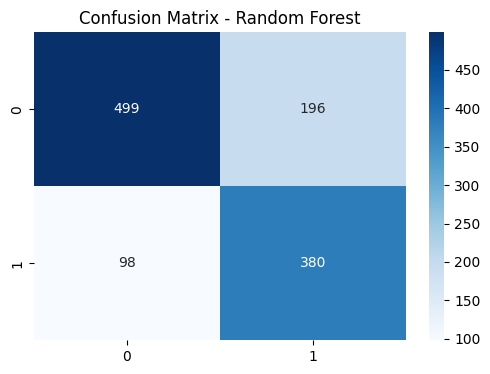

In [36]:
# Confusion Matrix for Best Model

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")

plt.savefig("../outputs/charts/churn_prediction/confusion_matrix.png")

plt.show()

In [37]:
# Feature Importance for Best Model

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
5,ActiveDays,0.380400
3,TotalQuantity,0.164843
1,Monetary,0.149227
0,Frequency,0.137365
2,AvgOrderValue,0.085794
4,AvgQuantity,0.082372


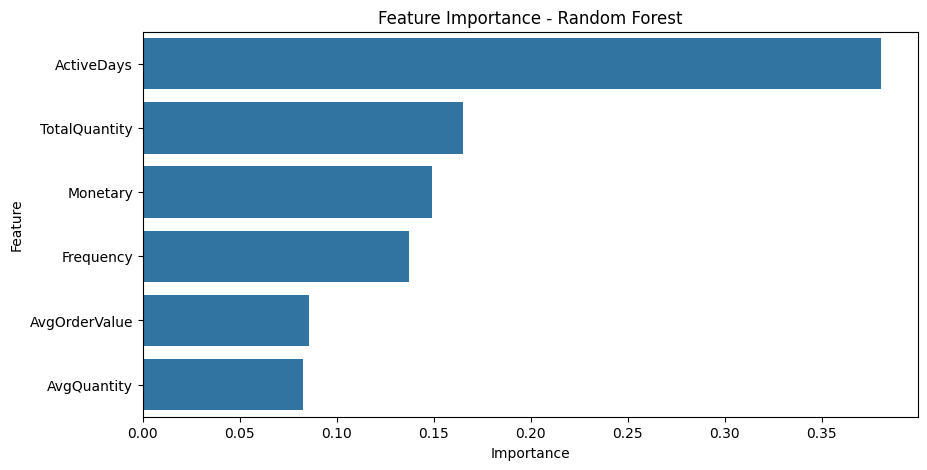

In [38]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title(f"Feature Importance - {best_model_name}")

plt.savefig("../outputs/charts/churn_prediction/feature_importance.png")

plt.show()

In [39]:
# Save churn prediction results

customer_features.to_csv(
    "../outputs/churn_prediction_results.csv"
)

print("Churn prediction results saved successfully!")

Churn prediction results saved successfully!


Churn Prediction Insight

Both Random Forest and XGBoost models were trained and evaluated for churn prediction. Although XGBoost was tested as recommended in the project specification, Random Forest achieved stronger performance on this dataset based on ROC-AUC and Precision@Top20%. Therefore, Random Forest was selected as the final churn prediction model.

The final model achieved strong predictive capability and showed that customer engagement duration, purchase quantity, and spending behavior were the most important churn indicators.